# Trabalho Final - notebook base do projeto da Julia

In [1]:
# Bibliotecas usadas na análise: pandas para manipular os dados,
# matplotlib e seaborn para os gráficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **O nível médio de ansiedade varia conforme o tempo de uso das redes sociais e a quantidade de sono?**

(nível de ansiedade, tempo diário de uso de redes sociais, horas de sono)

--- **Aviso importante sobre a natureza dos dados:** o conjunto de dados usado neste trabalho
(*Teen Mental Health & Social Media Usage Dataset*, Kaggle) é declarado pelo próprio autor, na página
de publicação, como um **dataset sinteticamente gerado** ("This is a synthetically generated dataset
created for educational, analytical, and machine learning purposes. It does not contain real personal
information and should not be used for clinical diagnosis..."). Ou seja, as 1.200 pessoas deste
arquivo não existem de verdade — os valores foram produzidos por um gerador de dados, não coletados
de adolescentes reais. Por isso, os resultados deste notebook devem ser lidos como um **exercício de
técnica de análise exploratória** (como categorizar variáveis, comparar grupos, investigar
confundidores), e não como evidência real sobre saúde mental de adolescentes. Qualquer padrão
encontrado aqui reflete a lógica interna de quem gerou os dados, não um fenômeno do mundo real.

Feita essa ressalva, o objetivo declarado do notebook é avaliar como o nível de ansiedade
autorreferido varia conforme o tempo diário de uso de redes sociais e a quantidade de horas de sono,
dentro deste conjunto de 1.200 registros de adolescentes (13 a 19 anos).

In [2]:
# Carrega o dataset a partir do zip (contém um único CSV) e mostra as primeiras linhas
df = pd.read_csv("../datasets/julia/Teen_Mental_Health_Dataset.zip", compression='zip')

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# Nível de ansiedade autorreferido (variável-alvo da pergunta de pesquisa)
df["anxiety_level"].unique()

array([ 2,  1,  4,  7,  5, 10,  8,  9,  6,  3])

A variável **anxiety_level** é **numérica discreta** (nota autorreferida) e varia de 1 a 10
no dataset.

In [5]:
# Tempo diário de uso de redes sociais
df["daily_social_media_hours"].unique()

array([7.9, 1.9, 1.3, 7.4, 4.7, 2.5, 4. , 3.3, 7.2, 4.9, 6.2, 6.8, 5.7,
       3.6, 1.5, 3.1, 6.7, 1.2, 3.4, 4.1, 5.3, 2.3, 2.4, 2. , 6.6, 1.6,
       2.7, 5. , 4.6, 4.8, 6.3, 6.4, 7.3, 5.2, 4.5, 3.5, 2.9, 5.8, 7.1,
       4.3, 3.9, 7.5, 6.9, 1.1, 2.6, 5.4, 5.6, 1.8, 8. , 5.1, 3.2, 7.7,
       6.5, 7.8, 6. , 3.8, 2.1, 4.4, 3. , 7. , 7.6, 6.1, 5.9, 1.4, 4.2,
       1.7, 2.8, 2.2, 3.7, 5.5, 1. ])

A variável **daily_social_media_hours** é **numérica contínua** (horas por dia) e varia de
1.0 a 8.0 no dataset.

In [6]:
# Horas de sono por noite
df["sleep_hours"].unique()

array([7.4, 8. , 7.6, 6.9, 4.9, 4.4, 6.4, 4.2, 5. , 5.8, 4.7, 7.2, 5.7,
       5.9, 5.3, 6.1, 6.8, 4.6, 6.7, 8.7, 7.1, 5.6, 7.8, 7.3, 5.5, 4. ,
       8.6, 7.7, 8.8, 4.1, 4.8, 5.1, 6.3, 8.5, 4.5, 6.5, 8.2, 7. , 8.4,
       4.3, 7.5, 6. , 5.2, 9. , 5.4, 6.6, 8.1, 7.9, 8.9, 8.3, 6.2])

A variável **sleep_hours** é **numérica contínua** (horas por noite) e varia de 4.0 a 9.0
no dataset.

## Verificando a qualidade dos dados

In [7]:
# Verificando se há duplicatas
df.duplicated().sum()

np.int64(0)

In [8]:
# Se houver dados duplicados, verificamos quais são
df[df.duplicated()]

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label


**Conclusão 1:** não há linhas duplicadas no dataset analisado.

In [9]:
# Verificando se há valores faltantes (soma e porcentagem por coluna)
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({
    "Dados faltantes (soma)": dados_faltantes_soma,
    "Dados faltantes (porcentagem)": dados_faltantes_porc,
})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
age,0,0.0
gender,0,0.0
daily_social_media_hours,0,0.0
platform_usage,0,0.0
sleep_hours,0,0.0
screen_time_before_sleep,0,0.0
academic_performance,0,0.0
physical_activity,0,0.0
social_interaction_level,0,0.0
stress_level,0,0.0


**Conclusão 2:** não há nenhum valor faltante em nenhuma das 13 colunas do dataset. Isso
confirma, de forma independente, o que a própria página do Kaggle já informava ("No missing values").

## Limpeza do conjunto de dados

In [10]:
# Não há duplicatas nem valores faltantes a remover (Conclusões 1 e 2), então não há
# nenhuma linha de limpeza a executar aqui. Mantemos a seção para seguir a mesma estrutura
# das demais etapas do trabalho, mas sem rodar código que não teria efeito nenhum no dataset.
df.shape

(1200, 13)

**Conclusão 3:** não foi necessária nenhuma limpeza — o dataset já chega sem duplicatas e
sem valores faltantes em nenhuma coluna, então as 1.200 linhas originais permanecem todas na análise.

## Estatística descritiva

Utiliza as variáveis numéricas identificadas no início do trabalho para calcular estatísticas
descritivas pertinentes à pergunta de pesquisa.

In [11]:
# "sleep_hours" é numérica, então para comparar grupos de pessoas a transformamos em faixas
# (variável categórica). Existe uma referência real da literatura para quantidade de sono
# recomendada por faixa etária: Hirshkowitz et al. (2015), "National Sleep Foundation's sleep
# time duration recommendations", que recomenda 8 a 10 horas de sono por noite para
# adolescentes de 14 a 17 anos (a amostra deste dataset, 13 a 19 anos, se sobrepõe em boa
# parte a essa faixa). Usamos esse corte, mesmo sabendo que o dataset é sintético, porque a
# classificação em si é um critério real e não arbitrário.
df["faixa_sono"] = pd.cut(
    df["sleep_hours"],
    bins=[0, 8, 10, 24],
    right=False,
    labels=["Abaixo da recomendação (<8h)", "Dentro da recomendação (8-10h)", "Acima da recomendação (>10h)"],
)

# Confere quantas pessoas caíram em cada faixa
df["faixa_sono"].value_counts()

faixa_sono
Abaixo da recomendação (<8h)      962
Dentro da recomendação (8-10h)    238
Acima da recomendação (>10h)        0
Name: count, dtype: int64

**Nota sobre a faixa de sono:** a categoria "Acima da recomendação (>10h)" ficou vazia
(0 pessoas), porque o maior valor de `sleep_hours` no dataset é 9.0 horas — ninguém na amostra dorme
mais do que o teto de 10h da recomendação. Isso não é um erro; é simplesmente uma característica do
intervalo de valores gerado neste dataset. A maior parte da amostra (962 de 1.200, ou 80.2%) dorme
abaixo da faixa recomendada.

In [12]:
# "daily_social_media_hours" também é numérica. Diferente do sono, não existe uma
# classificação oficial de "uso excessivo de redes sociais" em horas por dia — órgãos de saúde
# não publicam um padrão equivalente ao de sono para esse tipo de uso. Por isso, dividimos em
# tercis (3 grupos de tamanho parecido) pelos próprios dados, e mostramos os cortes numéricos
# usados, já que rótulos como "Baixo/Médio/Alto" sozinhos não informam nada.
df["faixa_uso_rs"], cortes_uso = pd.qcut(
    df["daily_social_media_hours"], q=3, labels=["Baixo", "Médio", "Alto"], retbins=True
)

print(f"Cortes dos tercis de uso de redes sociais: Baixo = {cortes_uso[0]:.1f}-{cortes_uso[1]:.1f}h, "
      f"Médio = {cortes_uso[1]:.1f}-{cortes_uso[2]:.1f}h, Alto = {cortes_uso[2]:.1f}-{cortes_uso[3]:.1f}h")

print("\nPessoas por faixa de uso de redes sociais:")
print(df["faixa_uso_rs"].value_counts())

Cortes dos tercis de uso de redes sociais: Baixo = 1.0-3.5h, Médio = 3.5-5.6h, Alto = 5.6-8.0h

Pessoas por faixa de uso de redes sociais:
faixa_uso_rs
Baixo    425
Alto     399
Médio    376
Name: count, dtype: int64


In [13]:
# Calcula o nível médio de ansiedade em cada faixa de sono, para ver se dormir dentro ou
# abaixo da recomendação está associado a mais ou menos ansiedade
df_med_sono = df.groupby("faixa_sono", observed=True)[["anxiety_level"]].mean()

print("Nível médio de ansiedade por faixa de sono:")
print(df_med_sono)

print("\n################################\n")

print("Maior média encontrada:")
print(df_med_sono.max())
print("\nFaixa de sono correspondente à maior média:")
print(df_med_sono.idxmax())

print("\n################################\n")

print("Menor média encontrada:")
print(df_med_sono.min())
print("\nFaixa de sono correspondente à menor média:")
print(df_med_sono.idxmin())

Nível médio de ansiedade por faixa de sono:
                                anxiety_level
faixa_sono                                   
Abaixo da recomendação (<8h)         5.601871
Dentro da recomendação (8-10h)       5.777311

################################

Maior média encontrada:
anxiety_level    5.777311
dtype: float64

Faixa de sono correspondente à maior média:
anxiety_level    Dentro da recomendação (8-10h)
dtype: category
Categories (3, str): ['Abaixo da recomendação (<8h)' < 'Dentro da recomendação (8-10h)' < 'Acima da recomendação (>10h)']

################################

Menor média encontrada:
anxiety_level    5.601871
dtype: float64

Faixa de sono correspondente à menor média:
anxiety_level    Abaixo da recomendação (<8h)
dtype: category
Categories (3, str): ['Abaixo da recomendação (<8h)' < 'Dentro da recomendação (8-10h)' < 'Acima da recomendação (>10h)']


**Conclusão 4:** o nível médio de ansiedade é praticamente igual nas duas faixas de sono que
têm gente: 5.60 na faixa "Abaixo da recomendação" (962 pessoas) e 5.78 na faixa "Dentro da
recomendação" (238 pessoas) — uma diferença de apenas 0.18 ponto, numa escala de 1 a 10. Essa
diferença é pequena demais para indicar uma associação real entre quantidade de sono e ansiedade
nesta amostra.

In [14]:
# Calcula o nível médio de ansiedade em cada faixa de uso de redes sociais
df_med_uso = df.groupby("faixa_uso_rs", observed=True)[["anxiety_level"]].mean()

print("Nível médio de ansiedade por faixa de uso de redes sociais:")
print(df_med_uso)

print("\n################################\n")

print("Maior média encontrada:")
print(df_med_uso.max())
print("\nFaixa de uso correspondente à maior média:")
print(df_med_uso.idxmax())

print("\n################################\n")

print("Menor média encontrada:")
print(df_med_uso.min())
print("\nFaixa de uso correspondente à menor média:")
print(df_med_uso.idxmin())

Nível médio de ansiedade por faixa de uso de redes sociais:
              anxiety_level
faixa_uso_rs               
Baixo              5.470588
Médio              5.832447
Alto               5.629073

################################

Maior média encontrada:
anxiety_level    5.832447
dtype: float64

Faixa de uso correspondente à maior média:
anxiety_level    Médio
dtype: category
Categories (3, str): ['Baixo' < 'Médio' < 'Alto']

################################

Menor média encontrada:
anxiety_level    5.470588
dtype: float64

Faixa de uso correspondente à menor média:
anxiety_level    Baixo
dtype: category
Categories (3, str): ['Baixo' < 'Médio' < 'Alto']


**Conclusão 5:** o nível médio de ansiedade também varia pouco entre as faixas de uso de
redes sociais, e sem um padrão crescente claro: 5.47 no grupo de uso Baixo, 5.83 no Médio (o maior
valor) e 5.63 no Alto. Ou seja, o grupo de uso médio tem ansiedade ligeiramente maior que o de uso
alto, o que já indica que não há uma relação simples de "quanto mais uso, mais ansiedade" nesta
amostra.

In [15]:
# Como a pergunta menciona os dois fatores (sono E uso de redes sociais) ao mesmo tempo,
# cruzamos as duas faixas com uma tabela dinâmica (pivot_table), para ver se o nível de
# ansiedade muda quando as duas condições são combinadas
tabela_cruzada = df.pivot_table(
    index="faixa_uso_rs", columns="faixa_sono", values="anxiety_level",
    aggfunc="mean", observed=True,
)
print("Nível médio de ansiedade por faixa de uso de redes sociais x faixa de sono:")
print(tabela_cruzada)

print("\n################################\n")

# Conferimos também quantas pessoas caem em cada combinação, já que um grupo pequeno
# torna a média menos confiável
contagem_cruzada = df.pivot_table(
    index="faixa_uso_rs", columns="faixa_sono", values="anxiety_level",
    aggfunc="count", observed=True,
)
print("Quantidade de pessoas em cada combinação de faixas:")
print(contagem_cruzada)

Nível médio de ansiedade por faixa de uso de redes sociais x faixa de sono:
faixa_sono    Abaixo da recomendação (<8h)  Dentro da recomendação (8-10h)
faixa_uso_rs                                                              
Baixo                             5.501493                        5.355556
Médio                             5.847403                        5.764706
Alto                              5.470219                        6.262500

################################

Quantidade de pessoas em cada combinação de faixas:
faixa_sono    Abaixo da recomendação (<8h)  Dentro da recomendação (8-10h)
faixa_uso_rs                                                              
Baixo                                  335                              90
Médio                                  308                              68
Alto                                   319                              80


**Conclusão 6:** cruzando as duas faixas, o valor mais alto de ansiedade média aparece no
grupo Uso Alto + Sono Dentro da recomendação (6.26, mas com apenas 80 pessoas) e o mais baixo no
grupo Uso Baixo + Sono Dentro da recomendação (5.36, 90 pessoas) — uma diferença de 0.90 ponto, mas
entre dois subgrupos pequenos (80 e 90 pessoas de um total de 1.200), o que é compatível com
variação aleatória de amostragem, não necessariamente um padrão real. Não há uma tendência
consistente de "mais uso e menos sono = mais ansiedade" nas demais combinações da tabela.

In [16]:
# O padrão encontrado até aqui é fraco e pouco consistente. Antes de concluir que não há
# relação, verificamos a correlação linear entre as três variáveis numéricas originais
# (sem categorizar), que é outra forma de checar se existe alguma associação sendo perdida
# pela divisão em faixas
df[["daily_social_media_hours", "sleep_hours", "anxiety_level"]].corr()

,daily_social_media_hours,sleep_hours,anxiety_level
daily_social_media_hours,1.000000,-0.009472,0.027835
sleep_hours,-0.009472,1.000000,-0.011879
anxiety_level,0.027835,-0.011879,1.000000


**Conclusão 7:** a correlação entre `anxiety_level` e as outras duas variáveis é
praticamente nula: 0.03 com `daily_social_media_hours` e -0.01 com `sleep_hours` (numa escala de -1 a
1, onde 0 significa nenhuma relação linear). Isso confirma, por um caminho diferente do groupby, o
que as Conclusões 4, 5 e 6 já sugeriam: nesta amostra, o nível de ansiedade não varia de forma
relevante com o tempo de uso de redes sociais nem com a quantidade de sono. Vale registrar que a
própria página do dataset descreve uma relação embutida entre uso de redes sociais e a variável
`depression_label` (não `anxiety_level`) — ou seja, é possível que o gerador dos dados tenha
programado uma relação forte para uma variável de saúde mental (depressão), mas não para a variável
específica desta pergunta de pesquisa (ansiedade).

**Conclusão final (síntese):** dentro deste conjunto de dados sintético de 1.200
adolescentes, o nível médio de ansiedade **não mostrou uma variação relevante** conforme o tempo de
uso de redes sociais nem conforme a quantidade de sono — as diferenças entre grupos foram pequenas
(no máximo cerca de meio ponto numa escala de 1 a 10, exceto num subgrupo pequeno e pouco confiável)
e as correlações lineares ficaram praticamente em zero. Como o próprio dataset é declarado como
sinteticamente gerado pelo autor, essa ausência de padrão não pode ser lida como uma conclusão sobre
adolescentes reais — só indica que, para a variável `anxiety_level` especificamente, o gerador de
dados não parece ter embutido uma relação forte com uso de redes sociais ou sono (diferente do que
a própria página do dataset descreve para a variável de depressão). A resposta à pergunta de
pesquisa, portanto, é que **não foi encontrada associação relevante entre ansiedade e os dois
fatores estudados nesta amostra**, e essa conclusão deve ser interpretada exclusivamente como
característica deste conjunto de dados simulado, não como evidência sobre saúde mental de
adolescentes no mundo real.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

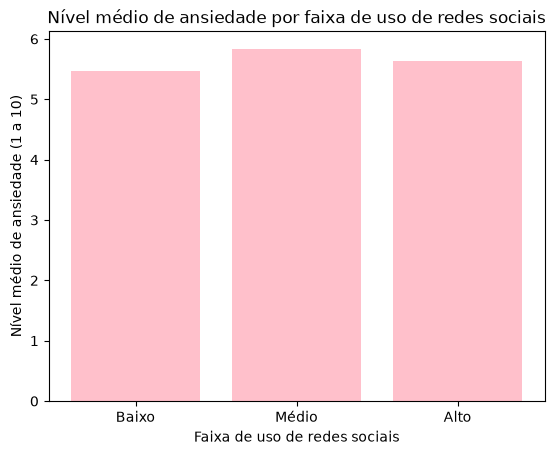

In [17]:
# Gráfico de barras: ansiedade média por faixa de uso de redes sociais
plt.bar(df_med_uso.index, df_med_uso["anxiety_level"], color="pink")
plt.title("Nível médio de ansiedade por faixa de uso de redes sociais")
plt.xlabel("Faixa de uso de redes sociais")
plt.ylabel("Nível médio de ansiedade (1 a 10)")
plt.show()

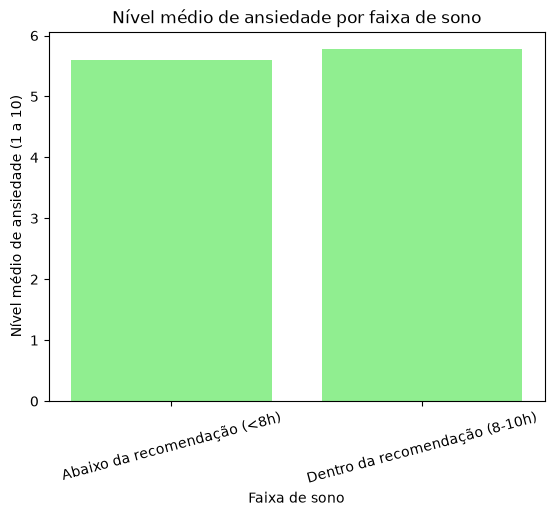

In [18]:
# Gráfico de barras: ansiedade média por faixa de sono
plt.bar(df_med_sono.index, df_med_sono["anxiety_level"], color="lightgreen")
plt.title("Nível médio de ansiedade por faixa de sono")
plt.xlabel("Faixa de sono")
plt.ylabel("Nível médio de ansiedade (1 a 10)")
plt.xticks(rotation=15)
plt.show()